# Assignment: Bayesian Optimization

Name of the students: .... WRITE YOUR NAME HERE


## Instructions

Write your name (or names if you are working in a group) in the cell above

Write your solution in the cell below the exercise. Some cell can be already partially completed to facilitate your work. If it more conveninent for you, feel free to rewrite the entire cell/solution instead of using the pre-filled cell.

## Suggestions

Whenever possible, print the final results to check correctness of the solution. For debugging and understanding, it is sometimes convenient also to print intermediate results.

Note: We do not care about your codes!! We only care about the final results!


## Delivery

The jupyter notebook should be executed from the beginning, running the notebook as follows: `Kernel -> Restart & Run All`. Check that the printed solutions are the ones you are expecting.

We will run your notebook. If it breaks, we will evaluate your exercise only up to the break.

Submission deadline: May, 3rd, 2026


## Final presentation

In your final presentation, you should only present and comment the results of Exercise 3. Indeed, Exercise 1 and Exercise 2 are only preparatory exercises to solve Exercise 3. However, in the evaluation of your jupyter notebook, we will also evaluate the solutions of Exercise 1 and 2.

## Aim of the exercise session

In this exercise session, you will implement your own Bayesian optimization (BO) algorithm to solve the maximization problem

$$
\max_{x} f(x) \ \ with \ \  x \in X
$$
where $x\in \mathbb{R}^{nx}$, $f(x)$ is the objective function you want to maximize, and $X$ is the feasible set where $x$ is constrained to belong to. For instance, $X$ can be a box.

In principle, the analytical expression of $f(x)$ is not known, and $f(x)$ can only be evaluated through experiments. Basically, for given $\bar x$, you can evaluate $y=f(\bar x) + e$, where $e$ is a noise term.


In order to implement the BO algorithm you will:
- First, practice with Gaussian Process (GP) regression using the sklearn package. This will be the topic of Exercise 1. Remind that GP is used in BO to build a surrogate of f(x).

- Second, practice with the Python function *minimize* from the *scipy.optimize* package, which aims at solving a generic minimization problem  
$$
\min_{x} a(x) \ \ with \ \  x \in X
$$
where the analytical expression of $a$ is KNOWN. This will be the topic of Exercise 2. You will need the Python function *minimize* in BO to maximize the acquisition function.

- Finally, implement the entire Bayesian Optimization algorithm. This will be the topic of Exercise 3.

## Exercise 1: Gaussian process regression

In this exercise we will use the *GaussianProcessRegressor* command from *sklearn* to solve a regression problem using GP

Let us import the required Python packages

In [162]:
%matplotlib inline
from sklearn.gaussian_process import GaussianProcessRegressor
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as mse

Let us now generate synthetic input/output data

$y = f(x) + e$,

where $x \in \mathbb{R}^{n_x}$ is the input, $f(x)$ is the underlying model generating the data, $e$ is a noise following a Gaussian distribution $N(0,\sigma_e^2)$.


## Exercise 1.1: data generation and plots (scalar case)

Define a Python function *y_scalar* to create the map $y=f(x)+e$, with $f(x)=sin(2x) - cos(3x+\pi) -0.05x^2$, and $e$ being a zero-mean Gaussian noise.

*y_scalar* takes as inputs:
- x: numpy array of size $N \times nx$, where $nx$ is the number of inputs and $N$ number of measurements
- sigmae: standard deviation of the noise $e$

The funtion returns:
- y: numpy array of size $N \times 1$, with $y=f(x)+e$



In [163]:
# TO BE COMPLETED

# definition of function y_scalar

# Hint: Use the command np.random.randn(N,1) to generate an array of dimension Nx1 of random variables with distribution
# N(0,1). Think how to generate random variables with distribution N(0,sigmae^2)?

def y_scalar(x, sigmae):

    fx = np.sin(2*x) - np.cos(3*x+np.pi) - 0.05*x**2
    e = sigmae * np.random.randn(x.shape[0], 1)

    # (N, nx) = x.shape
    y = fx + e

    return y

Generate values of x in the interval [-10, 10] and plot the function y=f(x)+e for:
- e: Gausian noise with standard deviation 0
- e: Gausian noise with standard deviation 0.25




In [164]:
# TO BE COMPLETED
# generate x (and reshape if needed)

x = np.linspace(-10, 10, 1000).reshape(-1, 1)



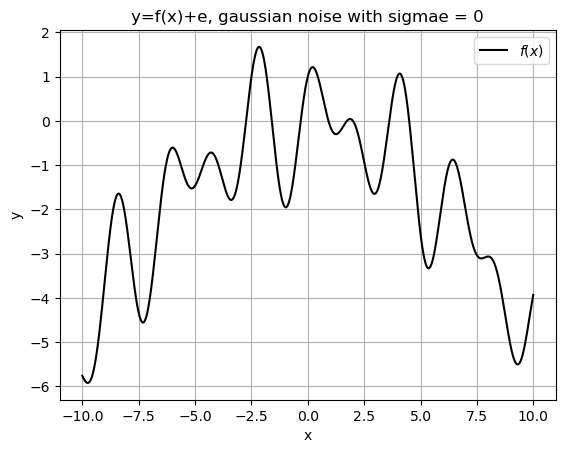

In [165]:
sigmae=0
y = y_scalar(x, sigmae)
function_max_0 = y

plt.figure()
plt.plot(x, y, "k", label="$f(x)$")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"y=f(x)+e, gaussian noise with sigmae = {sigmae}")
plt.legend()
plt.grid()
plt.show()

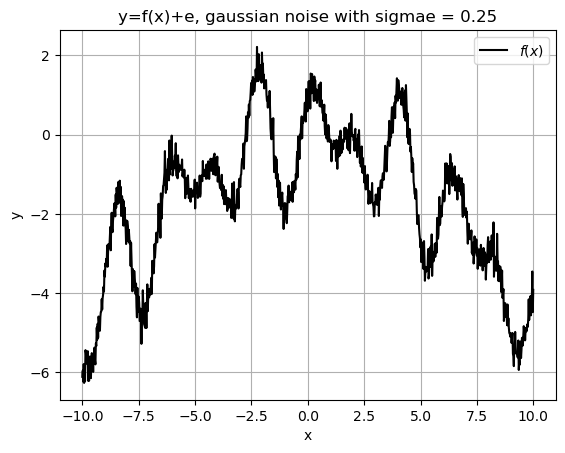

In [166]:
sigmae = 0.25
y = y_scalar(x, sigmae)
function_max_0_25 = y

plt.figure()
plt.plot(x, y, "k", label="$f(x)$")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"y=f(x)+e, gaussian noise with sigmae = {sigmae}")
plt.legend()
plt.grid()
plt.show()

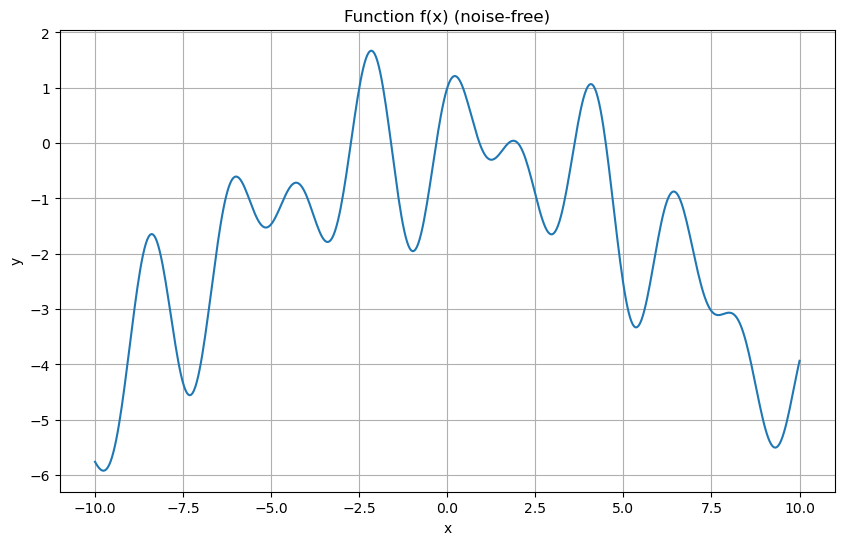

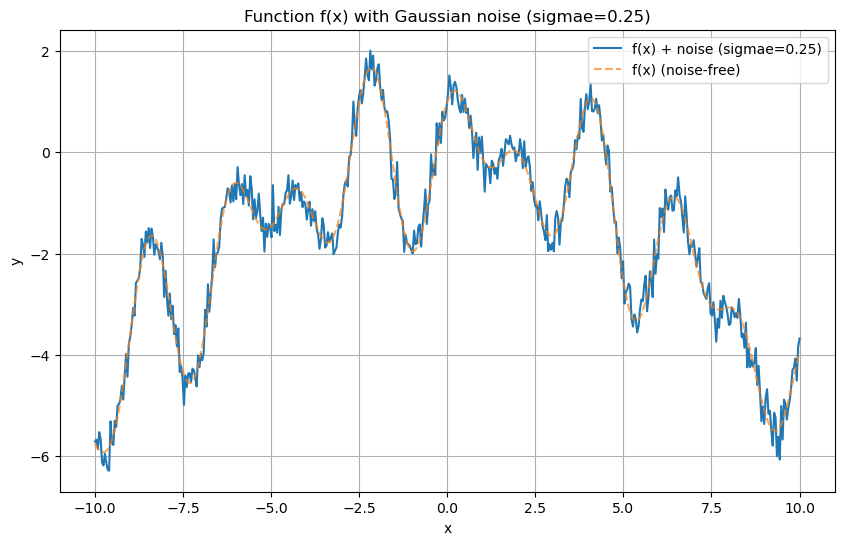

In [167]:
import matplotlib.pyplot as plt

# generate x values in the interval [-10, 10]
x = np.linspace(-10, 10, 500).reshape(-1, 1)

# --- Plot with sigmae=0 (no noise) ---
sigmae = 0
y_noise_free = y_scalar(x, sigmae)

plt.figure(figsize=(10, 6))
plt.plot(x, y_noise_free)
plt.title('Function f(x) (noise-free)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

# --- Plot with sigmae=0.25 (with Gaussian noise) ---
sigmae = 0.25
y_noisy = y_scalar(x, sigmae)

plt.figure(figsize=(10, 6))
plt.plot(x, y_noisy, label=f'f(x) + noise (sigmae={sigmae})')
plt.plot(x, y_noise_free, label='f(x) (noise-free)', linestyle='--', alpha=0.7)
plt.title(f'Function f(x) with Gaussian noise (sigmae={sigmae})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

- What is the maximum value of f(x), for $x \in [-10,  10]$?
- For which value of x the maximum of f(x) is attained?

To give an answer to this question you can either look at the plot of $f(x)$ or you can use the numpy commands $max$ (to compute the maximum of an array y) and $argmax$ (which gives you the index of the array y where the maximum value of $y$ is localted).

In the cell below, implement the second approach and visully compare the result you obtain using the first approach.

In [168]:
# TO BE COMPLETED

f_max =  np.max(function_max_0) # maximum value of f(x)
x_max = round(x[np.argmax(function_max_0)][0], 3) # value of x maximizing $f(x)$

print('Maximum value of f = ' + str(f_max))
print('Maximum value of f attained for x = ' + str(x_max))

Maximum value of f = 1.6713207359151283
Maximum value of f attained for x = 5.711


In [169]:
# Compute maximum for sigmae = 0.25
f_max_25 = np.max(function_max_0_25)
x_max_25 = round(x[np.argmax(function_max_0_25)][0], 3)


print(f"Maximum value of f = {round(f_max_25, 3)}")
print(f"Maximum value of f attained for  x = {x_max_25}")

Maximum value of f = 2.216
Maximum value of f attained for  x = 5.511


## Exercise 1.2: data generation and plots (multi-dimensional case)

Let us now consider a multi-dimensional case, i.e., $x \in \mathbb{R}^{nx}$, with $nx=3$.

Define a Python function *y_md* to create the map $y=f(x)+e$, with $x=[x0, x1, x2]$ and


$f(x)=sin(2*x0 -x1) - cos(3*x2+\pi-2*x1)-0.5*x1^2 - 0.1*(x2+5)^2  - 0.1*(x0-5)^2-10$

*y_md* takes as inputs:
- x: numpy array of size $N \times nx$, where $nx$ is the number of inputs and $N$ number of measurements
- sigmae: standard deviation of the noise $e$
and returns:
- y: numpy array of size Nx1, with $y=f(x)+e$

To avoid typos in the definition of the function, the expression of the functionm $f(x)$ is already provided in the cell below. If you want, feel free to modify it, but carefully double-check that the expression is correct.

In [170]:
from matplotlib.cbook import flatten
# TO BE COMPLETED


def y_md(x, sigmae):


    f_x = np.sin(2*x[:,0] -x[:,1] ) - np.cos(3*x[:,2]+np.pi-2*x[:,1])-0.5*x[:,1]**2 - 0.1*(x[:,2]+5)**2 -  0.1*(x[:,0]-5)**2 - 10
    e = (np.random.randn(x.shape[0],1) * sigmae).flatten()

    y = f_x + e

    return y



Compute the maximum of f(x), assuming that $x0\in [-10, 5]$,  $x1\in [-10, 5]$ and $x2\in [-10, 5]$? For which value of x is the maximum of f(x) attained?  

Note 1: At this stage of the exercise, you are not supposed to use any Python library for function maximization/minimization.

Note 2: DO NOT compute the maximum of f(x) analytically!

Suggestion: Evaluate the function $f(x)$ for different values of x0, x1, and x2, and then pick the maximum value.

In [171]:
x_mat = np.random.uniform(-10, 5, (100000, 3))
sigmae_25 = 0.25
y_mat = y_md(x_mat,sigmae_25)
x_mat.shape,y_mat.shape

((100000, 3), (100000,))

In [172]:
# TO BE COMPLETED
...

f_max = y_mat[0]
x_max = x_mat[0]

for n in range (1,len(y_mat)):

  if  y_mat[n] > f_max:
    f_max = y_mat[n]
    x_max = x_mat[n]

print('Maximum value of f = ' + str(f_max))
print('Maximum value of f attained for x = ' + str(x_max))



Maximum value of f = -7.963943239748788
Maximum value of f attained for x = [ 3.87275849  0.12175644 -4.23325317]


## Exercise 1.3: Linear regression (scalar case)

Let us consider the scalar function f(x) constructed above (Exercise 1.1). From the Python function *y_scalar* you created above, generate N=30 output samples y=f(x) + e, with x generated in the interval $[-10, 5]$ and let $e$ be a Gaussian random noise with standard deviation $\sigma=0.4$.

From the generated input-output samples, reconstruct the function using a Linear Regression algorithm. Generate a noise-free ($\sigma=0$) test set with at least 100 samples and assess the performance of your linear regression model. To assess performance, you can (for instance) compute the $R^2$ index; plot *x vs y* and *x vs y_lr*, where *y_lr* is the output of the linear regression model.

Does a linear regression model well fit your data?

Hint: For linear regression, you can use the *LinearRegression* module fromm *sklearn.linear_model*

In [173]:
# Generate training data
N = 30
sigmae_train = 0.4

np.random.seed(100)
x_tr = np.random.uniform(-10, 5, (N, 1))
y_tr = y_scalar(x_tr, sigmae_train)

# Generate a sorted noise-free test set, so the plot is readable
N_test = 200
x_test = np.linspace(-10, 5, N_test).reshape(-1, 1)
y_test = y_scalar(x_test, 0)

# Train linear regressor
reg = LinearRegression()
reg.fit(x_tr, y_tr)

# Assess performance in test set
y_lr = reg.predict(x_test)

print(f"R^2 : {reg.score(x_test, y_test):.4f}")
print(f"MSE : {mse(y_test, y_lr):.4f}")


R^2 : 0.4069
MSE : 1.8240


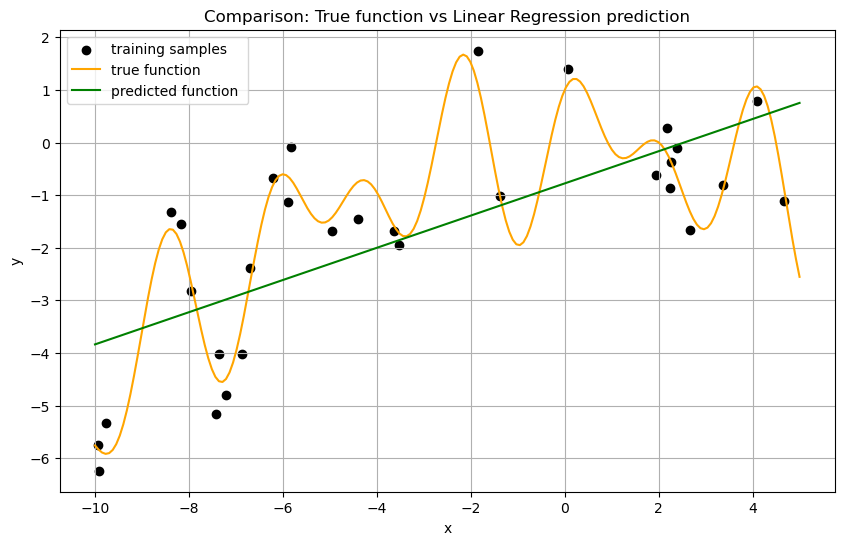

In [174]:
# plot of true values vs predicted



plt.figure(figsize=(10, 6))
plt.scatter(x_tr, y_tr, color="black", label="training samples")
plt.plot(x_test, y_test, color="orange", label="true function ")
plt.plot(x_test, reg.predict(x_test), color="green", label="predicted function ")
plt.title("Comparison: True function vs Linear Regression prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

## Exercise 1.4: Gaussian process regression (scalar case)

Let us consider the same training and test datasets used in Exercise 1.3, or generate new datasets of the same dimension.

Instead of using Linear regression, let us reconstruct the function $f(x)$ using Gaussian Process regression. The *code cell* below will guide you in implementing Gaussian Process Regression.

Note: IGNORE possible warnings which can appear during the training of the GP

In [194]:
# TO BE COMPLETED

#------------------------------------------------------------------------
# DO NOT CHANGE THIS PART
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0, noise_level_bounds=(1e-5, 1e0)) # Parameter used in Gaussian Process. DO NOT CHANGE THIS LINE
np.random.seed(100)
#---------------------------------------------------------------------------


# Generate training data (or use previous ones)
x_train= x_tr
y_train = y_tr

# Generate test data
x_test = np.linspace(-10,5,100).reshape(-1, 1)
y_test = y_scalar(x_test,0)


# Gaussian Process Regression (Note same synthax of other sklearn regressors)

gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20,random_state=100)
gpr.fit(x_train, y_train)

# Assess performance on training and test data

y_test_mean, sigma = gpr.predict(x_test,return_std=True)

print(f"R^2: {gpr.score(x_test,y_test)}")
print(f"MSE: {mse(y_test,y_test_mean)}")

c:\Users\kevin\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:305: RuntimeWarning: divide by zero encountered in log
  return np.log(np.hstack(theta))


R^2: 0.9193089880272913
MSE: 0.2514106891296948


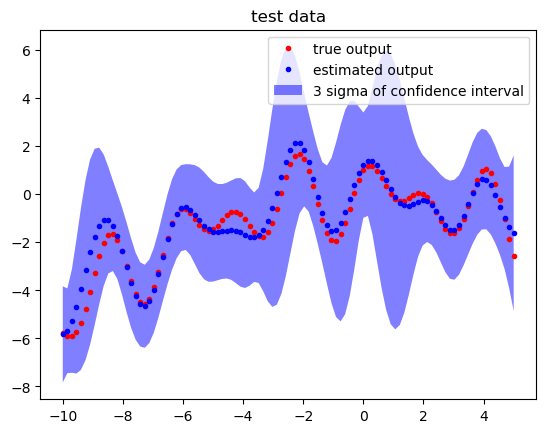

In [177]:


plt.figure()
plt.title('test data')


plt.plot(x_test, y_test, 'r.', label='true output')
plt.plot(x_test, y_test_mean, 'b.', label='estimated output')
plt.fill_between(x_test.reshape(-1),y_test_mean + 3 * sigma,y_test_mean - 3 * sigma,alpha=0.5,
    fc="b",
    ec="None",
    label="3 sigma of confidence interval"
)

plt.legend()
plt.show()

In [178]:
# # TO BE COMPLETED

# #------------------------------------------------------------------------
# # DO NOT CHANGE THIS PART
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF, WhiteKernel
# kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0, noise_level_bounds=(1e-5, 1e0)) # Parameter used in Gaussian Process. DO NOT CHANGE THIS LINE
# np.random.seed(100)
# #---------------------------------------------------------------------------


# # Generate training data (or use previous ones)
# x_tr <- np.random.uniform(-10, 5, (N, 1))
# y_tr = y_scalar(x_tr, n_siga)

# # Generate test data
# x_test = np.linspace(-10,5,100).reshape(-1, 1)
# y_test = y_scalar(x_test,0)


# # Gaussian Process Regression (Note same synthax of other sklearn regressors)

# gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20)
# gpr.fit(x_tr, y_tr)

# # Assess performance on training and test data

# y_test_mean, sigma = gpr.predict(x_test,return_std=True)

# print(f"R^2: {gpr.score(x_test,y_test)}")
# print(f"MSE: {mse(y_test,y_test_mean)}")




Test the performance of the model on a new test set, with inputs $x$ in the interval $[-10, \ 10]$ (not anymore in the interval $[−10,5]$). What do you observe in the extrapolating region $[5, 10]$? Where you expecting this behaviour?

In [ ]:
# TO BE COMPLETED
x_test = np.linspace(-10,10,100).reshape(-1, 1)
y_test = y_scalar(x_test,sigmae = 0)


y_test_mean, y_test_stddev = gpr.predict(x_test, return_std=True)
print(f"R^2: {gpr.score(x_test,y_test)}")
print(f"MSE: {mse(y_test,gpr.predict(x_test))}")


R^2: 0.1860031658185226
MSE: 2.8433886657283285


Gaussian processes also return uncertainty on the prediction, by simply setting the parameter *return_std = True* in doing prediction, i.e.,

y_mean, y_std = gpr.predict(x, return_std=True)

where y_mean, y_std are the mean and standard deviation of the estimate.

Compute mean and standard deviation of the prediction for test points in the interval $[-10, 10]$.

In the same figure, plot true ouput, mean of the estimated output, mean of the estimated output $\pm$ 3xstandard deviation.

Comment the obtained results? What do you observe in the extrapolated region (namely, in the interval $[5, 10]$)?

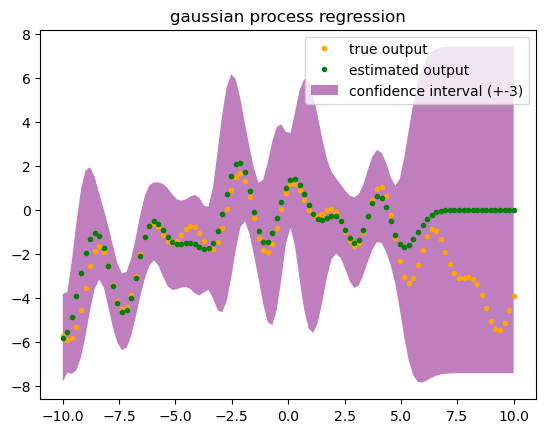

In [180]:
# TO BE COMPLETED
y_test_mean, y_test_stddev = gpr.predict(x_test, return_std=True)

plt.figure()
plt.title("gaussian process regression")
plt.plot(x_test, y_test, ".", color="orange", label="true output")
plt.plot(x_test, y_test_mean, ".",color="green", label="estimated output")

plt.fill_between(x_test.reshape(-1), y_test_mean + 3*y_test_stddev, y_test_mean - 3*y_test_stddev, alpha=0.5, label='confidence interval (+-3)', color='purple', ec='None')
plt.legend()
plt.show()


## Exercise 1.5: Gaussian process regression (multi-dimensional input)

Let us now repeat exercise 1.4, using as a function $f(x)$ the multidimensional function defined in Exercise 1.2. Complete the steps below.

From the Python function *y_md* you created in Exercise 1.2, generate N=50 training samples, with output y=f(x) + e, with x generated in the box [−10,5]x[−10,5]x[−10,5], and let 𝑒 be a Gaussian random noise with standard deviation 𝜎=0.1.

From the generated samples, fit a Gaussian Process regressor and evaluate the performance in the training points. To assess performance, use the function *score* and plot the true output vs the estimated output and 3x standard deviation.

Assess the performance also in a test set, with inputs x generated in the box [−10,5]x[−10,5]x[−10,5].

In [195]:
# TO BE COMPLETED

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0, noise_level_bounds=(1e-5, 1e0)) # Parameter used in Gaussian Process. DO NOT CHANGE THIS LINE
np.random.seed(100)


# Generate training data
N = 50 # Number of samples
x_train = np.random.rand(N,3)*15-10
y_train = y_md(x_train, 0.1)

# Generate test data
N_test = 100 # Number of samples
x_test = np.random.rand(N_test, 3)*15-10
y_test = y_md(x_test,sigmae=0)

# Gaussian Process Regression
gpr = GaussianProcessRegressor(kernel)
gpr.fit(x_train, y_train)


# evaluate performance
y_pred = gpr.predict(x_test)

# result of trainng set 
y_pred_train, y_std_train = gpr.predict(x_train, return_std=True)
print(f"training R²: {gpr.score(x_train, y_train):.3f}")
print(f"training MSE: {mse(y_train, y_pred_train):.3f}")
print(f"STD: {y_std_train.mean()}")
print()

# result of test
y_pred_test, y_std_test = gpr.predict(x_test, return_std=True)
print(f"test R²: {gpr.score(x_test, y_test):.3f}")
print(f"test MSE: {mse(y_test, y_pred_test):.3f}")
print(f"STD: {y_std_test.mean()}")



training R²: 1.000
training MSE: 0.000
STD: 0.004870274542459108

test R²: 0.876
test MSE: 31.438
STD: 4.471820407821924


c:\Users\kevin\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:305: RuntimeWarning: divide by zero encountered in log
  return np.log(np.hstack(theta))


Let us now assess the performance in an extrapolation test set, with inputs x generated in the box [5,10]x[5,10]x[5,10].

Compute the score, and plot true output, mean of the estimated output, mean $\pm$ 3xstandard deviation of the estimated output.

What can you say about the standard deviation achieved for points in the box $[-10, 5]$ and the one achieved in the interval $[5, 10]$?

In [198]:
# TO BE COMPLETED

# Generate test data
N_test = 100 # Number of samples
np.random.seed(999)
x_test_5_to_10 = np.random.rand(N_test, 3)*5 + 5
y_test_5_to_10 = y_md(x_test, 0)  # NO noise

# Assess performance on new test data
y_pred_5_to_10, y_std_5_to_10 = gpr.predict(x_test_5_to_10, return_std=True)

print(f"R^2: {gpr.score(x_test_5_to_10, y_test_5_to_10):.3f}")
print(f"MSE: {mse(y_test_5_to_10, y_pred_5_to_10):.3f}")
print(f"STD: {y_std_5_to_10.mean()}")

R^2: -5.063
MSE: 1532.069
STD: 33.702988540336655


# Exercise 2 - Function optimization

In this exercise, we will maximize a known function a(x) subject to constraints.

Basically, we aim to solve the following optimization problem:

$$
\max_x a(x) \ s.t. \ x \in \mathcal{X}
$$

where $\mathcal{X}$ is the feasible set (namely, admissible values of $x$). For example, $x$ can be a box, with lower and upper limits for the input.

In this exercise, as a function to be maximized, we consider the parabola:

$a(x) = -(x_0-a)^2 - (x_1-b)^2 - (x_2-c)^2 + 1$, with constraints $x_0,x_1,x_2 \in [-2, 2]$ and parameters:
a=0.5; b = 0; c = -1.5

## Exercise 2.1

For the considered function a(x) there is actually no need to use any Python solver to find its maximum. In fact, its maximum can be computed analytically. What's the maximum value of $a(x)$? What's the maximizer of $a(x)$ (namely, what is the value of $x$ such that $a(x)$ is maximal)?

TO BE COMPLETED

You can write here your solution:



## Exercise 2.2

Let us now forget the fact that maximum of $a(x)$ can be computed analytically, and let use a numerical Python solver to compute its maximum. We will use the Python function *minimize* imported from *scipy.optimize*.

The first thing to do is to define a function $a(x)$. Since we want to maximize $a(x)$ instead of minimizing, we directly define $-a(x)$.

Let us define the function $-a(x)$ which takes as inputs:

    x: numpy array of size nx, where nx is the number of inputs (nx=3) in our example

    a, b, c: parameters a, b, c characterizing the function a(x). In our example:  a = 0.5, b = 0, c = -1.5

returns y=-a(x) (float)


In [183]:
# TO BE COMPLETED

def minus_a(x, a, b, c):  #define -a(x)

    y = ...

    return y

# test your function
x = [0, 1 ,2]
y = minus_a(x, a = 0.5, b = 0, c = -1.5)

print(f"Obtained value of y=-a(x) = {y}")  # Expected value 12.5

Obtained value of y=-a(x) = Ellipsis


Let us now define bounds (lower and upper limits) for the three input variables $x_0, x_1, x_2$. Bounds should be defined as a list of tuples, as follows:

bounds = [(x0_min, x0_max), (x1_min, x1_max),  (x2_min, x2_max) ]

where xi_min and xi_max represent, respectively, lower and upper limit of the variable xi.

In the following cell, please define the bounds for your optimization problem.

In [184]:
#TO BE COMPLETED

bounds = [...]

We can now use the Python function *minimize* to solve the minimization problem

$$\min_x -a(x) \ s.t. \ x \in bounds $$

Check that the obtained result (namely, minimum value of -a(x) and corresponding minimizer x) is the one you computed analytically in Exercise 2.1.

In [185]:
# TO BE COMPLETED
from scipy.optimize import minimize

x0 = [0, 0, 0] # Initial guess where to start the optimization

...


#results are saved in the attributes of the object res, in particular at attributes "fun" and "x"

print(f"minimum value of -a(x). -a*= {...}")
print(f"minimizer of -a(x). x* = {...}")

minimum value of -a(x). -a*= Ellipsis
minimizer of -a(x). x* = Ellipsis


Often, the numerical solvers in Python (or any other programming language) are sensitive to the initial guess where the optimization starts.

Repeat the exercise above starting the optimization for 100 different initial guesses of  $x0$. Pick the best solution (namely, the smallest minimum value of -a(x) among the 100 solutions)

In [186]:
# TO BE COMPLETED



# Exercise 3. Bayesian optimization

In this exercise, we will maximize the objective function $f(x)$ already defined and created in Exercise 2.1, and given by

$f(x)=sin(2*x0 -x1) - cos(3*x2+\pi-2*x1)-0.5*x1^2 - 0.1*(x2+5)^2  - 0.1*(x0-5)^2-10$

Each input $x_0,x_1,x_2$ is constrained to belong to the interval $[-10, 5]$.

As it is typical in Bayesian optimization, we will actually assume that we do not have an analytical expression of $f(x)$, and the only way to evaluate $f(x)$ is to observe $y=f(x)+e$ (with $e$ a noise) for given values of $x$. In the exercise, we assume $e$ is a zero-mean random Gaussian noise with standard deviation $\sigma_e=0.1$.


We would like to reach a value of $f(x)$ "close" to its maximum through a "small number" of evaluation of f(x). From now on, each evaluation of $f(x)$ for a given x will be called experiment.

# Exercise 3.1 Initialize the algorithm

Let us start with $N_{init}=5$ random experiments.

Generate $N_{init}=5$ random initial values of $x$ in the feasibility intervals $[-10, 5]$, and evaluate $y=f(x)+e$. Plot number of experiment vs observed $y$.

In [187]:
# TO BE COMPLETED
import numpy as np
import matplotlib.pyplot as plt

sigmae = 0.1
N_init = 5

np.random.seed(10) # You can decide to remove this line, or fix a seed for reproducibility of the results

x = ... #generate random values of x in the considered intervals
y = ...

# Plot number of experiment vs y (namely, observed noisy values of f(x))

...

Ellipsis

# Exercise 3.2 Computation of the surrogate

Next step of Bayesian optimization is to compute a surrogate function of $f(x)$. Our surrogate function will be a Gaussian process.

Define a function *compute_surrogate* that takes as inputs the observed input-output pairs (x,y) and returns the estimate Gaussian Process Regressor as an instance of the class *GaussianProcessRegressor()* of the library sklearn.gaussian_process

Assess performance of your surrogate model by plotting observed output vs predicted output (mean $\pm$ standard deviation). Do not be suprised if, in your training points, the standard deviation is very close to 0.

In [188]:
# TO BE COMPLETED (compute the surrogate model and assess performance)

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel


def compute_surrogate(x, y):

    # Inputs:
    # x: sampled inputs: numpy array of size (N,nx)
    # y: observed outputs: numpy array of size N

    kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-8, 10e1)) # Parameter used in Gaussian Process. DO NOT CHANGE THIS LINE
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20)  # do not change this line

    ... # fit your model gpr to your data (x, y)

    return gpr

gpr = compute_surrogate(x, y)

# Assess performance on the training data

...

Ellipsis

# Exercise 3.3 Acquisition function

So far, you have performed $N_{init}=5$ experiments. Which experiment to perform now? In other words, which is the next input $x^{(N+1)}$ where f(x) should be evaluated? The value of $x^{(N+1)}$ where to evaluate $f(x)$ is the one that maximizes the acquisition function $a(x)$. The acquisition function $a(x)$ balances the trade-off between exploitation (try points where you think there is the optimum) and exploration (search in unexplored regions)

Among many possible acquisition functions, we can create it by looking at the improvement we expect:

$$
EI(x) = \mathbb{E}\left[ \max( f_{GP}(x) -  f^*,0) \right]
$$
where $f^*=\max_{i=1,...,N} \mu (x^{(i)})$, $f_{GP}$ is the previously constructed surrogate of $f$ and $\mu$ its mean.

For Gaussian process, we have an analytical expression of the Expected Improvement, given by:

$$
EI(x) = \mathbb{E}\left[ \max( f_{GP}(x) -  f^*,0) \right] = \left( \mu(x) -  f^* \right) \Phi(Z) + \sigma(x)\phi(Z)
$$
where $Z = \frac{\mu(x) - f^*}{\sigma(x)}$, $\phi(.)$ is the normal probability density function, and $\Phi(.)$ is the normal cumulative distribution function.

Exercise: create the acquisition function $a(x)=EI(x)$.

In particular, define a Python function $EI$ which takes as input:

- x: numpy arrax of size (N, nx) where to evaluate EI(x)
- gpr: trained Gaussian Process Regressor modelling the surrogate $f(x)$
- f_star: float $f^*$ defined in the cell above

and returning as an output the value of the expected improvement EI(x).

Hint: Given Z, the probability density function $\phi(Z)$  and the cumulative distribution function $\Phi(Z)$ of a Normal distribution can be computed, respectively, through the Python functions norm.pdf(Z) and norm.cdf(Z) imported from the Python module *scipy.stats*.

In [189]:
# TO BE COMPLETED

from scipy.stats import norm  # used to compute phi(Z) and Phi(Z)

def EI(x, gpr, f_star):

    mu, sig = ...  # compute mean and standard deviation of the Gaussian process
    mu = mu.reshape(-1,1)
    sig = sig.reshape(-1,1)

    Z = ...
    phi = norm.pdf(Z)
    PHI = norm.cdf(Z)

    acq = ... # compute value of the acquisition function

    return acq

Evaluate $EI(x)$ at the training points you used to compute the surrogate, and at other points in the considered input domain $x_1, x_2, x_3 \in [-10, 5]$.  Compute the maximum of $EI(x)$ at the points used for training, and at points not used for training. Print the obtained results

Are you surprise that the maximum of $EI(x)$ at the new points is larger than the maximum at the trainig points? Why yes? Why no?

In [190]:
# TO BE COMPLETED


Use the function *minimize* from scipy.optimize to compute the maximum of the expected improvement $EI(x)$ over all possible values of $x$ in the considered domain. Note: In order to maximime $EI(x)$, you should actually consider $-EI(x)$ as objective function for *minimize*.

Repeat the optimization for different initial conditions, and pick the solution with maximum value of $EI(x)$.

Exercise. In the cell below you are asked to

1) define a new function *min_EI* (similar to the already defined Python function *EI*) which returns $-EI(x)$.

2) implement a function *select_next(x, gpr)* which takes as inputs:

    -- x: training inputs: numpy array of size (N, nx)    
    
    -- gpr: surrogate Gaussian Process of the objective function $f$  
    
    and returns:
    - the next value $x_{N+1}$ where to evaluate $x$
    
    - EI(x_{N+1}).
    
    The value of  $x_{N+1}$ is the one maximizing the acquisition function $EI(x)$.
    
Print the value of $x_{N+1}$ and the corresponding $EI(x_{N+1})$

In [191]:
#  TO BE COMPLETED

from scipy.optimize import minimize

def min_EI(x, gpr, f_star): # define here -EI(x). It shoulbe similar to EI(x, gpr, f_star), but it should return -EI(x)

    ...


def select_next(x, gpr, verbose = True):

    # compute x_next by maximizing the acquisition function EI(x) (or by minimizing EI(x))
    x_next = ...

    return x_next, EI(x_next.reshape(1,-1), gpr, f_star)


# Print x_next and corresponding EI
...


Ellipsis

# Exercise 3.4 Bayesian Optimization - complete loop

Now, you should have all the ingredients to implement a Bayesian Optimization algorithm.

The maximum number of experiments to be performed (not including the initial $N_{init}=5$ experiments) to try to find the maximum is $N_{max} = 50$.


We remind you all the steps:

1. Generate an initial dataset $\mathcal{D}$ with input-output pairs $\mathcal{D}=\{ x_i,y_i\}_{i=1}^{N_{init}}$. [Note: In your exercise, $N_{init} = 5$]


2. for iter 1,...,$N_{max}$ [Note: in your exercise $N_{max}=50$]

    2.1. Compute a surrogate model (Gaussian process) describing input-output relation in the dataset $\mathcal{D}$
    
    2.2 Define your acquisition function $EI(x)$

    2.3 Compute next experiment to perform by maximizing the acquisition function $x_{next} = arg\max_{x}EI(x)$
    
    2.4 Make experiment and observe $y_{next}$ [Note: In your example, generate $y_{next} = f(x_{next}) + e$]
    
    2.5 Augment the dataset $\mathcal{D} = \mathcal{D} \cup \{x_{next},y_{next}\}$


In [192]:
# TO BE COMPLETED

# re-initialize your algorithms or use the $N_init=5$ experiments defined few cells above

...

# Bayesian optimization loop

n_iter = 50

for iter in range(n_iter):

    print(iter)

    # complete this loop by implementing the 5 steps defined in the cell above

    ...

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


In [193]:
# SOLUTION

# re-initialize
N_init = 5
sigmae = 0.1

np.random.seed(10)
x = np.random.rand(N_init,3)*15-10 #generate random values of y in the considered intervals
y = y_md(x,sigmae=sigmae)

gpr = compute_surrogate(x, y)

# iteration

n_iter = 50

for iter in range(n_iter):

    print(iter)

    x_next, EI_opt = select_next(x, gpr, verbose = False) # evaluate next point where to query f(x)
    y_next = y_md(x_next.reshape(-1,nx),sigmae=sigmae) #evaluate y_next = f(x_next) + e

    x = np.concatenate((x, x_next.reshape(-1,nx))) # concatenate x and x_next
    y = np.concatenate((y, y_next)) # concatenate y and y_next
    gpr = compute_surrogate(x, y) # update surrogate



0


AttributeError: 'ellipsis' object has no attribute 'reshape'

Exercise: analyze the obtained results.

You can:

- plot the observed y as a function of the experiments.
- print the observed maximum value of $y$. Is it similar to the "true one"? Note that you have approximately computed the "true maximum of f(x)" in exercise 1.
- How many experiments did you need to compute the maximum value of $y$ (or at least, a value close to the maximum)?

In [ ]:
# TO BE COMPLETED


...


# Presentation

For your ppt presentation, you can:

1. Describe the problem you want to solve
2. Show the plot with "observed output y vs number of experiment"
3. Comment the results. Which is the maximum value you were expecting? Were you able to obtain it? Or, at least, were you able to obtain a result close to the maximum? After how many experiments are you able to reach a value close to the optimum?
4. Any other considerations
5. Be ready to reply to questions regarding the algorithm you implemented
6. You have to present only Exercise 3